This file merges data from different files in preparation for analyses

In [10]:
import pandas as pd
import numpy as np
import os
d = os.getcwd()+"/"
PATH_RAW = f"{d}/../data"
PATH_DATA = f"{d}/../data"
PATH_OUTPUT = f"{d}/../output"

df = pd.read_csv(f"{PATH_DATA}/data_full.csv" , index_col='date', parse_dates=True)

We have a dataset constructed for analysis:

In [11]:
print(df.head(2))
print(df.columns)
print(df.shape)

            XIMP1001  XIMP1002  XIMP1003  XIMP1004  XIMP1005  XIMP1006  \
date                                                                     
2015-01-01       NaN       NaN       NaN       NaN       NaN       NaN   
2015-02-01       NaN       NaN       NaN       NaN       NaN       NaN   

            XIMP1007  XIMP1008  XIMP1009  XIMP1010  ...     UNTL9305  \
date                                                ...                
2015-01-01       NaN       NaN       NaN       NaN  ...  1527.528952   
2015-02-01       NaN       NaN       NaN       NaN  ...  1547.019815   

               UNTL9306     UNTL9307      UNTL9308       UNTL9309  \
date                                                                
2015-01-01  2638.613595  9255.949361  11427.284839  337465.967092   
2015-02-01  2650.099592  9243.623917  11720.094728  341293.498691   

                UNTL9310     UNTL9100    UNTL9101       UNTL9300     UNTL9301  
date                                                     

The dataset includes the output variable, GDP

<Axes: xlabel='date'>

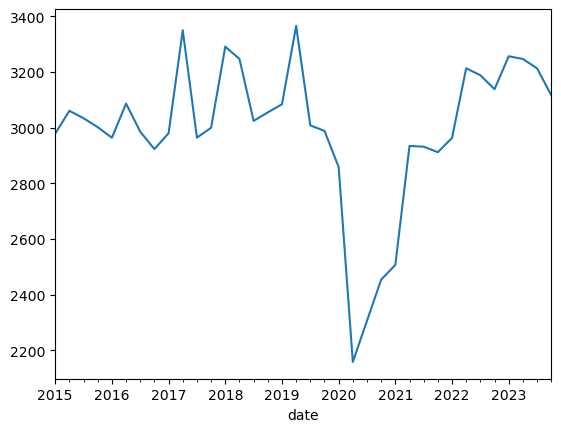

In [12]:
df['RGDP0000'].dropna().plot()

We wish to include **google trends** and **nighttime lights** data on our main data

First, let's remove the old variables

In [13]:
df[[ col for col in df.columns if "GTR" in col or "BMB" in col ]].tail(5)

,UBMB0000,UGTR0001,UGTR0010,UGTR0011,UGTR0012,UGTR0101,UGTR0017,UGTR0018,UGTR0019,UGTR0020,...,UGTR0097,UGTR0098,UGTR0099,UGTR0008,UGTR0100,UGTR0104,UGTR0009,UGTR0000,UGTR1000,UGTR1001
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,11358.881961,20.0,25.0,0.0,0.0,17.0,91.0,55.0,20.0,79.0,...,27.0,45.0,30.0,45.0,55.0,43.0,39.0,48.0,38.942308,41.256098
2025-10-01,11969.108872,21.0,11.0,1.0,NaN,13.0,94.0,67.0,7.0,70.0,...,24.0,40.0,29.0,18.0,67.0,36.0,36.0,48.0,37.215686,38.839506
2025-11-01,12403.084011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-01,10302.984993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
data = df[[ col for col in df.columns if "GTR" not in col and "BMB" not in col ]]

The dataset now doesn't include these variables:

In [15]:
data[[ col for col in data.columns if "GTR" in col or "BMB" in col ]].tail(5)

""
date
2025-09-01
2025-10-01
2025-11-01
2025-12-01
2026-01-01


In [16]:
data

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UNTL9305,UNTL9306,UNTL9307,UNTL9308,UNTL9309,UNTL9310,UNTL9100,UNTL9101,UNTL9300,UNTL9301
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1527.528952,2638.613595,9255.949361,11427.284839,337465.967092,42882.663753,5789.395704,144.040785,100257.966261,1744.129213
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1547.019815,2650.099592,9243.623917,11720.094728,341293.498691,42971.461661,5865.171518,144.736560,101307.169749,1758.042836
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1544.037683,2694.847317,9229.314139,10789.711109,340481.421106,43592.447236,5887.671888,148.735441,101023.223398,1740.365332
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1500.749469,2655.038560,9227.752361,11578.220148,332986.772405,43018.825816,6039.217265,156.465035,99202.892682,1743.786808
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1492.329894,2711.515342,9211.068250,10968.372061,331826.246042,44017.432352,6205.401452,164.940816,99005.779676,1740.388638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2630.285944,1589.287487,9320.677361,14831.968402,631351.046481,31570.512558,6441.473674,177.621960,171768.551200,2035.330128
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Google Trends

In [17]:
df = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
df.head(5)

,gt_bahamas_hotels_united_states,gt_242_jobs_bahamas,gt_wendys_bahamas,gt_kfc_bahamas,gt_bamboo_shack_bahamas,gt_mcdonalds_bahamas,gt_apple_bahamas,gt_samsung_bahamas,gt_iphone_bahamas,gt_android_bahamas,...,gt_harbour_island_bahamas,gt_disney_world_bahamas,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas
date,,,,,,,,,,,,,,,,,,,,,
2004-01-01,100,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,59,0,0,0,0
2004-02-01,83,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2004-03-01,81,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2004-04-01,76,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2004-05-01,67,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
df[df.index=='2025-05-01']

,gt_bahamas_hotels_united_states,gt_242_jobs_bahamas,gt_wendys_bahamas,gt_kfc_bahamas,gt_bamboo_shack_bahamas,gt_mcdonalds_bahamas,gt_apple_bahamas,gt_samsung_bahamas,gt_iphone_bahamas,gt_android_bahamas,...,gt_harbour_island_bahamas,gt_disney_world_bahamas,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas
date,,,,,,,,,,,,,,,,,,,,,
2025-05-01,33,24,66,89,65,28,68,26,47,17,...,32,42,0,50,30,58,22,39,25,42


Keep only data with enough observations

In [19]:
# Transform zeroes into np.nan
df = df.replace(0, np.nan)

# Keep only in the time period of the main database
df = df[df.index>=data.index.min()]

# drop columns with too many (75%) nan
df = df.dropna(axis=1, thresh=0.25 * len(df))

# Generate a column with the average
df['gt_all_mean'] = df.mean(axis=1)

In [20]:
df['gt_all_mean']

date
2015-01-01    37.482759
2015-02-01    36.672727
2015-03-01    36.850000
2015-04-01    39.000000
2015-05-01    38.688525
                ...    
2025-09-01    45.552239
2025-10-01    41.391304
2025-11-01    45.264706
2025-12-01    49.971014
2026-01-01    41.478873
Name: gt_all_mean, Length: 133, dtype: float64

<Axes: xlabel='date'>

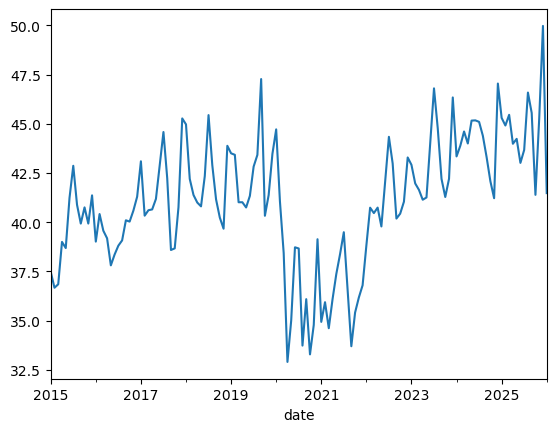

In [21]:
df['gt_all_mean'].plot()

In [22]:
data = pd.concat([ data , df] , axis=1).sort_index()
data.tail(5)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,gt_disney_world_bahamas,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas,gt_all_mean
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.0,NaN,42.0,38.0,58.0,16.0,44.0,53.0,40.0,45.552239
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.0,9.0,32.0,23.0,44.0,15.0,45.0,30.0,36.0,41.391304
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.0,NaN,41.0,24.0,43.0,24.0,51.0,39.0,42.0,45.264706
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,33.0,NaN,49.0,42.0,36.0,32.0,59.0,55.0,36.0,49.971014
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.0,3.0,35.0,9.0,46.0,16.0,64.0,20.0,43.0,41.478873


## Nighttime Lights

In [23]:
df = pd.read_csv(f"{PATH_RAW}/blk_ntl.csv", parse_dates=True, index_col='date')
df.tail(5)

,NearNadir_Composite_Snow_Free,DNB_BRDF-Corrected_NTL
date,,
2025-09-01,35295.062058,NaN
2025-10-01,37500.775735,NaN
2025-11-01,41424.880729,NaN
2025-12-01,40592.384046,NaN
2026-01-01,57200.455668,57200.455668


We are only interested in one column.

<Axes: xlabel='date'>

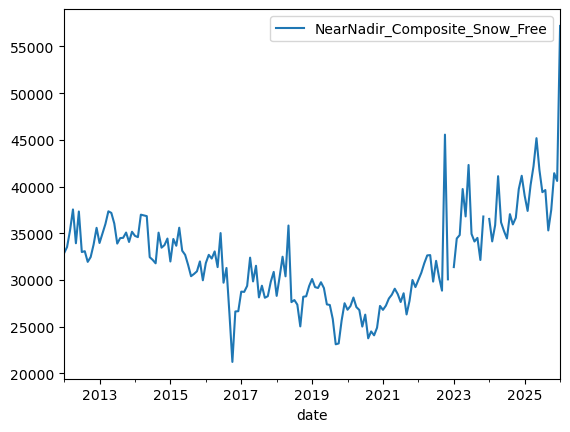

In [24]:
df = df[['NearNadir_Composite_Snow_Free']]
df.plot()

<Axes: xlabel='date'>

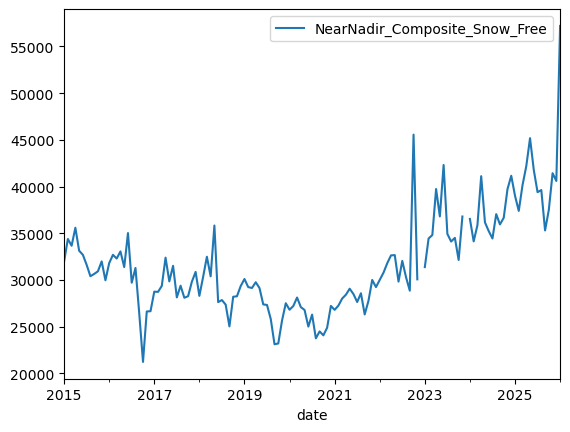

In [25]:
df = df[df.index>=data.index.min()]
df.plot()

In [26]:
data = pd.concat([ data , df] , axis=1).sort_index()
data.tail(5)

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,gt_rooms_to_go_bahamas,gt_fedex_bahamas,gt_700_wines_and_spirits_bahamas,gt_jobs_bahamas,gt_fresh_market_bahamas,gt_airbnb_bahamas_worldwide,gt_kraven_bahamas,gt_linkedin_bahamas,gt_all_mean,NearNadir_Composite_Snow_Free
date,,,,,,,,,,,,,,,,,,,,,
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,42.0,38.0,58.0,16.0,44.0,53.0,40.0,45.552239,35295.062058
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,32.0,23.0,44.0,15.0,45.0,30.0,36.0,41.391304,37500.775735
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.0,24.0,43.0,24.0,51.0,39.0,42.0,45.264706,41424.880729
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,49.0,42.0,36.0,32.0,59.0,55.0,36.0,49.971014,40592.384046
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,35.0,9.0,46.0,16.0,64.0,20.0,43.0,41.478873,57200.455668


## Labels

This section changes the variable titles using the metadata

In [27]:
metadata = pd.read_csv(f"{PATH_DATA}\meta_full.csv")
metadata

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\guerr\AppData\Local\Temp\ipykernel_8112\3087221582.py:1: SyntaxWarning: invalid escape sequence '\m'
  metadata = pd.read_csv(f"{PATH_DATA}\meta_full.csv")


,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
0,R,gdp,NaN,RGDP0000,q,2,0,1,0,1,0,2,mean
1,M,cpi,NaN,MCPI0000,m,0,0,1,0,0,0,1,mean
2,X,imports_animal_and_vegetable_oils_and_fats,NaN,XIMP1001,q,0,1,1,0,1,0,0,mean
3,X,imports_beverages_and_tobacco,NaN,XIMP1002,q,0,1,1,0,1,0,0,mean
4,X,imports_chemicals,NaN,XIMP1003,q,0,1,1,0,1,0,0,mean
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,U,NearNadir_Composite_Snow_Free,NaN,UBMB0000,m,1,0,1,0,1,0,0,mean
413,U,gt_wendy_s_bs,NaN,UGTR0101,m,1,0,1,0,1,0,0,mean
414,U,gt_kelly_s_bs,NaN,UGTR0102,m,1,0,1,0,1,0,0,mean
415,U,gt_solomon_s_bs,NaN,UGTR0103,m,1,0,1,0,1,0,0,mean


If the variables in data do not exist in the metadata, we construct it

In [28]:
max_under_1000 = (
    metadata['ticket']
    .str.extract(r'UGTR(\d+)', expand=False)
    .astype(float)          # allows NaN safely
    .loc[lambda x: x < 1000]
    .max()
)

metadata.series = metadata.series.str.replace(" ", "_")
new_series = []
for col in [ col for col in data.columns if col not in list(metadata['series'].unique()) and col not in list(metadata['ticket'].unique()) ] :
    max_under_1000 = max_under_1000 + 1
    new_series.append(
        {'series': col,
         'freq': 'm' ,
         'ticket' : f'UGTR0{str(int(max_under_1000))}' ,
         'unstructured' : 1,
         'block_g' : 1,
         'block_s' : 0,
         'block_r' : 1 ,
         'block_l' : 0 , 
         'nominal' : 0 ,
         'months_lag' : 0,
         'agg_method' : 'mean'
         }
    )

print(new_series)
metadata = pd.concat( [ metadata, pd.DataFrame(new_series) ] )

[{'series': 'gt_bahamas_hotels_united_states', 'freq': 'm', 'ticket': 'UGTR0105', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_242_jobs_bahamas', 'freq': 'm', 'ticket': 'UGTR0106', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_wendys_bahamas', 'freq': 'm', 'ticket': 'UGTR0107', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_kfc_bahamas', 'freq': 'm', 'ticket': 'UGTR0108', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, {'series': 'gt_bamboo_shack_bahamas', 'freq': 'm', 'ticket': 'UGTR0109', 'unstructured': 1, 'block_g': 1, 'block_s': 0, 'block_r': 1, 'block_l': 0, 'nominal': 0, 'months_lag': 0, 'agg_method': 'mean'}, 

In [29]:
for _, row in metadata.iterrows():
    series_name = row['series']
    ticket_name = row['ticket']
    if series_name in data.columns:
        data.rename(columns={series_name: ticket_name}, inplace=True)

In [30]:
data

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UGTR0168,UGTR0169,UGTR0170,UGTR0171,UGTR0172,UGTR0173,UGTR0174,UGTR0175,UGTR1001,UBMB0000
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,46.0,NaN,57.0,15.0,12.0,NaN,35.0,37.482759,31968.301562
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,50.0,NaN,56.0,NaN,13.0,NaN,36.0,36.672727,34378.729066
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.0,56.0,NaN,72.0,9.0,10.0,NaN,31.0,36.850000,33654.358441
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.0,58.0,NaN,53.0,NaN,11.0,NaN,42.0,39.000000,35585.079266
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.0,50.0,NaN,54.0,NaN,12.0,NaN,34.0,38.688525,33121.994187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,42.0,38.0,58.0,16.0,44.0,53.0,40.0,45.552239,35295.062058
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,32.0,23.0,44.0,15.0,45.0,30.0,36.0,41.391304,37500.775735
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.0,24.0,43.0,24.0,51.0,39.0,42.0,45.264706,41424.880729


In [31]:
metadata[metadata['series'].str.contains('mean')]

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
320,U,gt_select_mean,NaN,UGTR1000,m,1,0,1,0,1,0,0,mean
321,U,gt_all_mean,NaN,UGTR1001,m,1,0,1,0,1,0,0,mean
322,U,ntl1_airport_meanw90,NaN,UNTL9103,m,1,0,1,0,1,0,0,mean
323,U,ntl1_consumption_meanw90,NaN,UNTL9104,m,1,0,1,0,1,0,0,mean
324,U,ntl1_hotel_meanw90,NaN,UNTL9105,m,1,0,1,0,1,0,0,mean
325,U,ntl1_ports_meanw90,NaN,UNTL9106,m,1,0,1,0,1,0,0,mean
330,U,ntl3_airport_meanw90,NaN,UNTL9303,m,1,0,1,0,1,0,0,mean
331,U,ntl3_consumption_meanw90,NaN,UNTL9304,m,1,0,1,0,1,0,0,mean
332,U,ntl3_hotel_meanw90,NaN,UNTL9305,m,1,0,1,0,1,0,0,mean
333,U,ntl3_ports_meanw90,NaN,UNTL9306,m,1,0,1,0,1,0,0,mean


In [33]:
data[['UGTR1001', 'UBMB0000', 'RGDP0000']]

,UGTR1001,UBMB0000,RGDP0000
date,,,
2015-01-01,37.482759,31968.301562,NaN
2015-02-01,36.672727,34378.729066,NaN
2015-03-01,36.850000,33654.358441,2978.5
2015-04-01,39.000000,35585.079266,NaN
2015-05-01,38.688525,33121.994187,NaN
...,...,...,...
2025-09-01,45.552239,35295.062058,NaN
2025-10-01,41.391304,37500.775735,NaN
2025-11-01,45.264706,41424.880729,NaN


Lastly, to avoid issues, resample into monthly data

In [34]:
data = data.resample('MS').mean()
data

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,UGTR0168,UGTR0169,UGTR0170,UGTR0171,UGTR0172,UGTR0173,UGTR0174,UGTR0175,UGTR1001,UBMB0000
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,46.0,NaN,57.0,15.0,12.0,NaN,35.0,37.482759,31968.301562
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,50.0,NaN,56.0,NaN,13.0,NaN,36.0,36.672727,34378.729066
2015-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.0,56.0,NaN,72.0,9.0,10.0,NaN,31.0,36.850000,33654.358441
2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.0,58.0,NaN,53.0,NaN,11.0,NaN,42.0,39.000000,35585.079266
2015-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.0,50.0,NaN,54.0,NaN,12.0,NaN,34.0,38.688525,33121.994187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,42.0,38.0,58.0,16.0,44.0,53.0,40.0,45.552239,35295.062058
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,32.0,23.0,44.0,15.0,45.0,30.0,36.0,41.391304,37500.775735
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,41.0,24.0,43.0,24.0,51.0,39.0,42.0,45.264706,41424.880729


Save the file

In [ ]:
#data = data[[ col for col in data.columns if "BMB" not in col ]]

In [35]:
data.to_csv(f'{PATH_RAW}/data.csv')

**Last minute edit**

In [44]:
df1 = pd.read_csv(f"{PATH_RAW}/data_full_nov25_AM.csv" , index_col='date', parse_dates=True)
df1 = df1[[col for col in df1.columns if "UGTR" not in col and "UBMB" not in col and "UNTL" not in col]]
df1

,XIMP1001,XIMP1002,XIMP1003,XIMP1004,XIMP1005,XIMP1006,XIMP1007,XIMP1008,XIMP1009,XIMP1010,...,XEXP0030,XEXP0040,XEXP0000,XIMP0010,XIMP0020,XIMP0030,XIMP0040,XIMP0000,GPRI0000,GPRI0001
date,,,,,,,,,,,,,,,,,,,,,
2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.775736,245.123216,249.387641,3.423802,4.073190,88.989234,393.914705,490.400931,99874630.0,210138868.0
2025-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.762105,103.847888,109.335577,18.640987,4.046632,59.603282,386.757675,469.048575,-6341228.0,332993743.0
2025-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.572884,NaN,3.778058,2.873043,2.691152,1668.368095,NaN,1673.932290,NaN,NaN


In [45]:
# Fill missing values in data using the values from df1
data2 = data.combine_first(df1)

In [62]:
data2.to_csv(f'{PATH_RAW}/data.csv')

In [61]:
data2 = data2[data2.index>='2015-01-01']